In [1]:
import os 
import numpy as np 
import matplotlib.pyplot as plt

from locscale.include.emmer.ndimage.map_utils import load_map, save_as_mrc 
from locscale.include.emmer.ndimage.fsc_util import plot_fsc_maps, calculate_fsc_maps 
from locscale.include.emmer.ndimage.filter import get_cosine_mask


In [19]:
halfmap_1_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/halfmap_fsc_shifts/EMD-3061-half-1.map"
halfmap_2_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/halfmap_fsc_shifts/EMD-3061-half-2.map"
mask_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/halfmap_fsc_shifts/EMD_3061_unfiltered_confidenceMap.mrc"

feature_enhanced_1 = "/home/abharadwaj1/papers/elife_paper/figure_information/data/halfmap_fsc_shifts/emd_3061_fe_halfmap1.mrc" 
feature_enhanced_2 = "/home/abharadwaj1/papers/elife_paper/figure_information/data/halfmap_fsc_shifts/emd_3061_fe_halfmap2.mrc"

halfmap1, apix = load_map(halfmap_1_path)
halfmap2, _ = load_map(halfmap_2_path)
mask, _ = load_map(mask_path)
# Load feature-enhanced halfmaps
halfmap1_fe, _ = load_map(feature_enhanced_1)
halfmap2_fe, _ = load_map(feature_enhanced_2)

mask_binarised = (mask > 0.5).astype(int) 
mask_smooth = get_cosine_mask(mask_binarised, 5)

masked_halfmap1 = halfmap1 * mask_smooth
masked_halfmap2 = halfmap2 * mask_smooth
masked_halfmap1_fe = halfmap1_fe * mask_smooth
masked_halfmap2_fe = halfmap2_fe * mask_smooth
fsc_halfmaps_original = calculate_fsc_maps(masked_halfmap1, masked_halfmap2)

In [4]:
fsc_fe1_half2 = calculate_fsc_maps(halfmap1_fe, masked_halfmap2)

In [5]:
fsc_fe2_half1 = calculate_fsc_maps(masked_halfmap1, halfmap2_fe)

In [6]:
fsc_fe1_fe2 = calculate_fsc_maps(halfmap1_fe, halfmap2_fe)

In [10]:
from locscale.include.emmer.ndimage.plots import pretty_plot_radial_profile
from locscale.include.emmer.ndimage.profile_tools import frequency_array

In [9]:
freq = frequency_array(fsc_fe1_fe2, apix=apix)

/home/abharadwaj1/miniconda3/envs/py311/lib/python3.11/site-packages/locscale/include/emmer/ndimage/plots.py:91: RuntimeWarning: invalid value encountered in sqrt
  ax2.set_xticklabels([round(1/np.sqrt(x),1) for x in ax1.get_xticks()])
/home/abharadwaj1/miniconda3/envs/py311/lib/python3.11/site-packages/locscale/include/emmer/ndimage/plots.py:91: RuntimeWarning: divide by zero encountered in scalar divide
  ax2.set_xticklabels([round(1/np.sqrt(x),1) for x in ax1.get_xticks()])


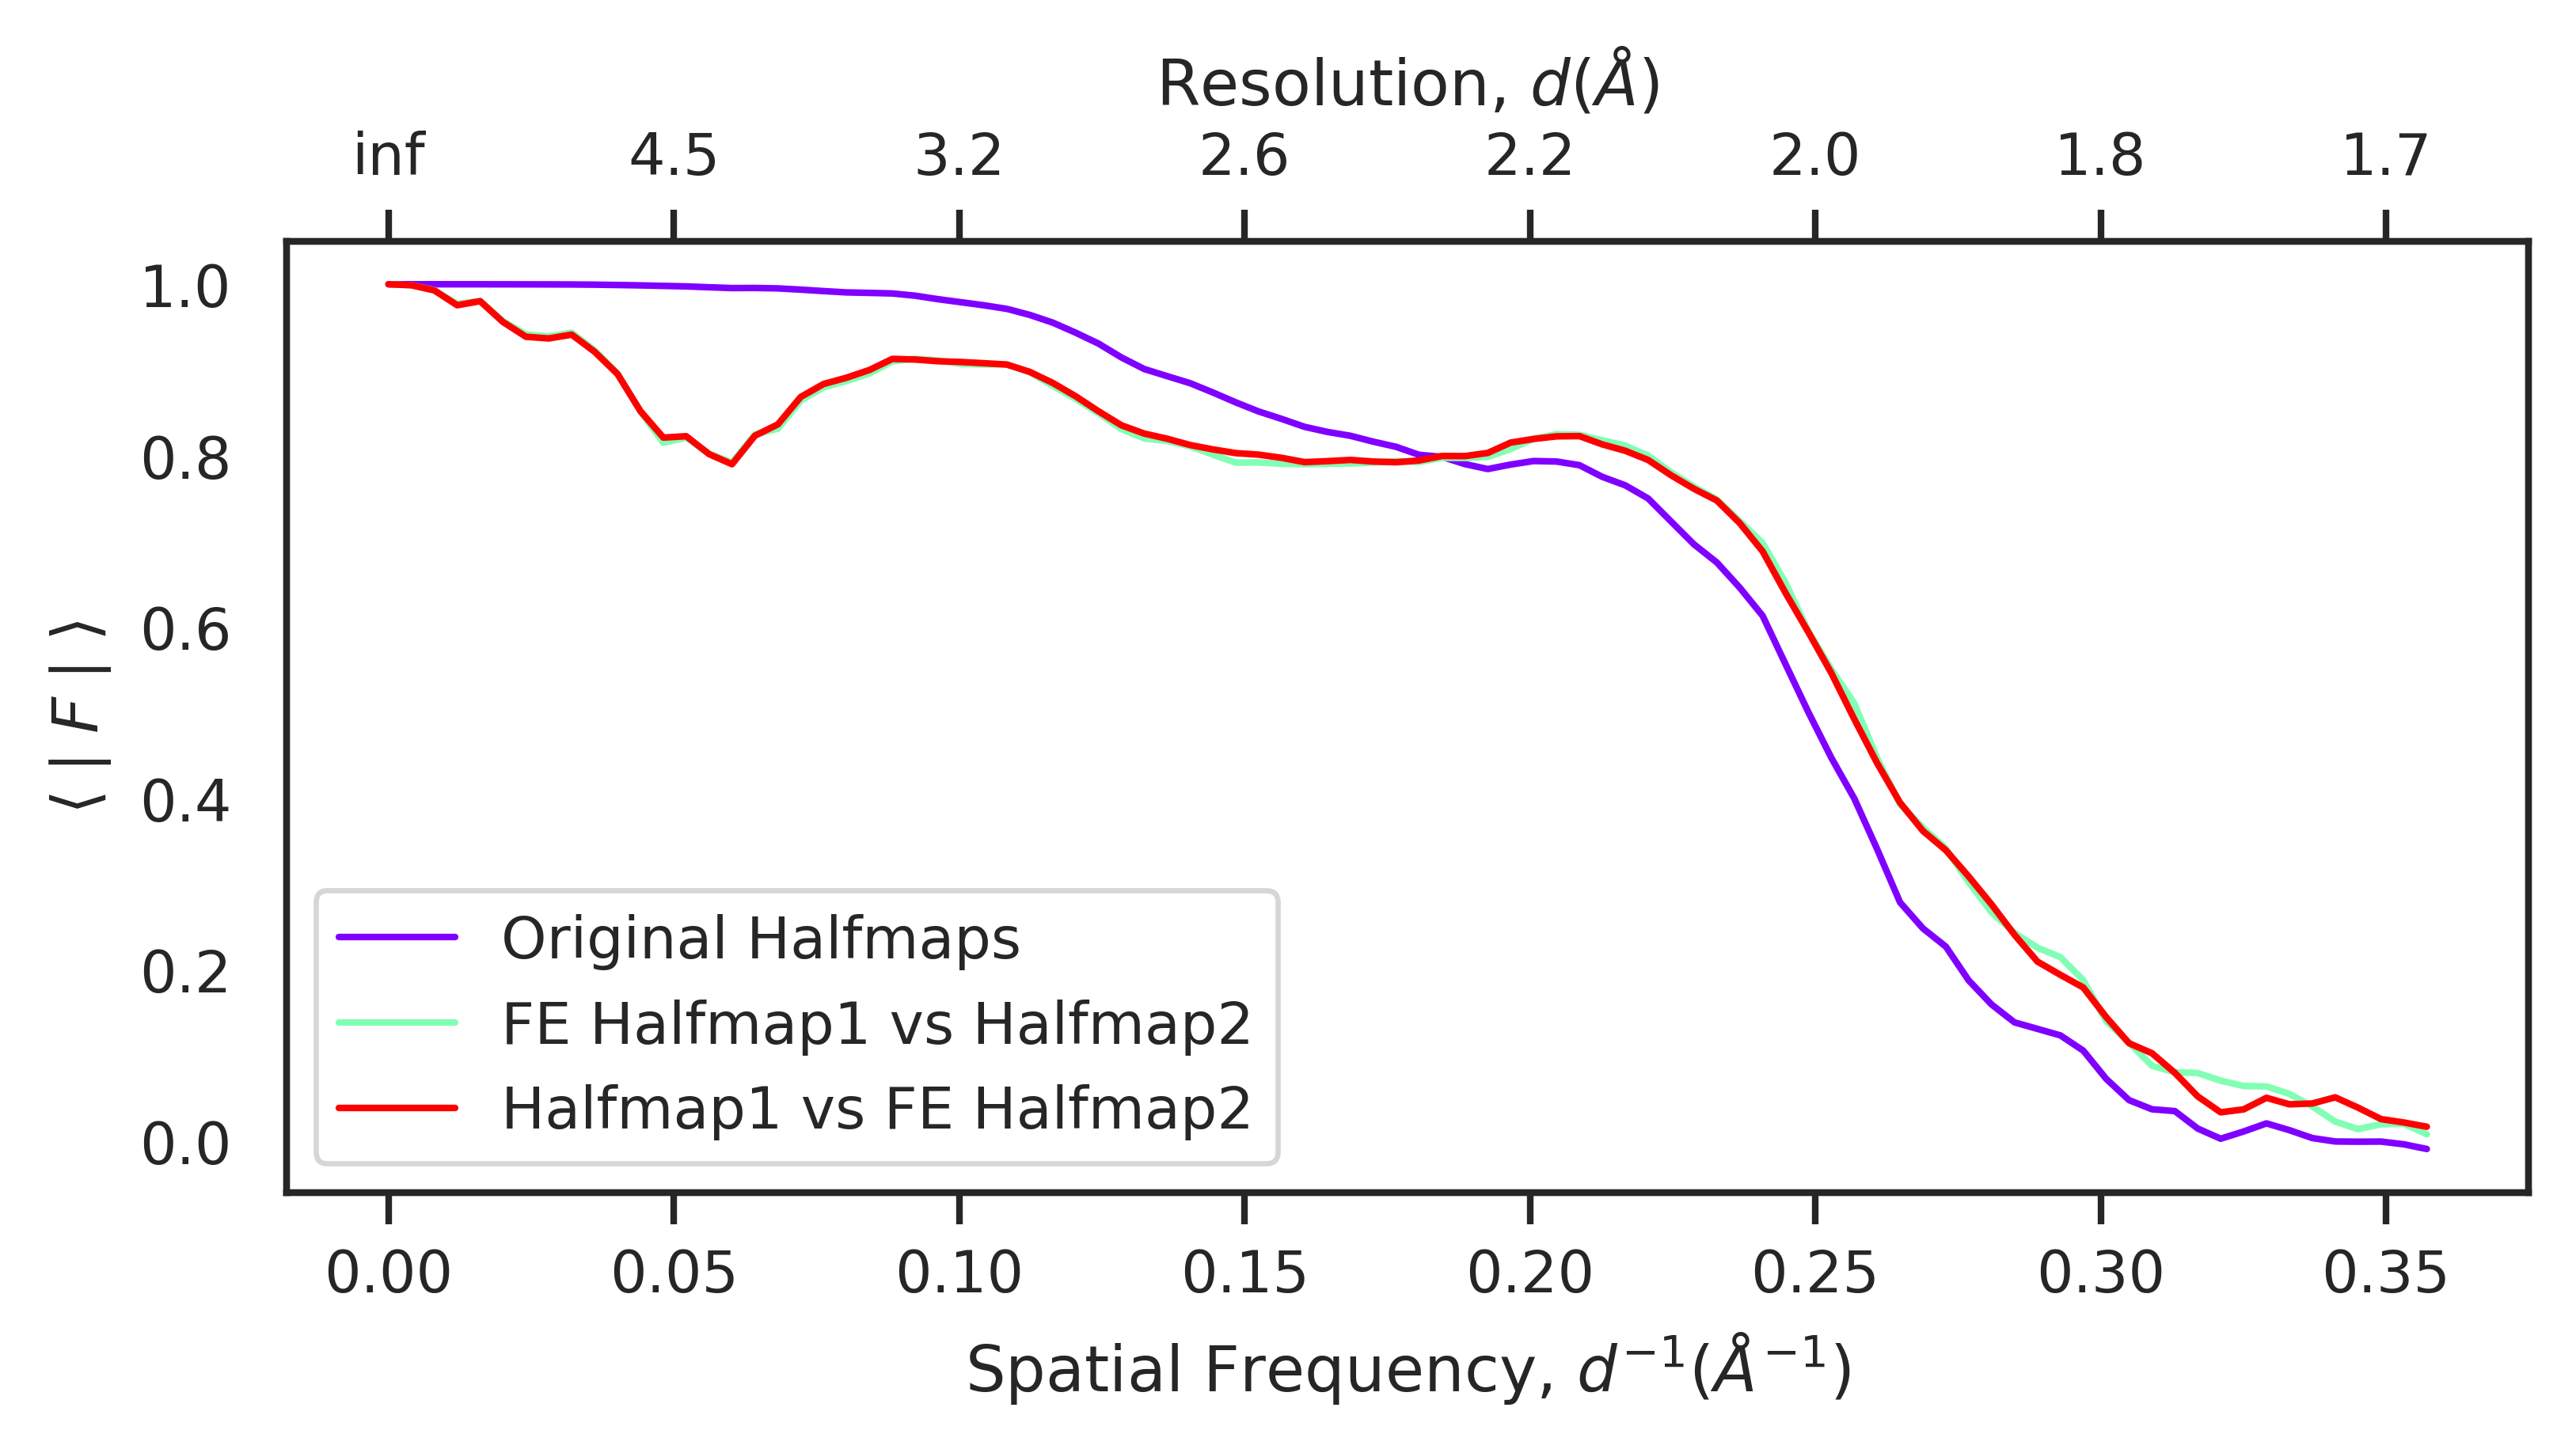

In [14]:
figplots = pretty_plot_radial_profile(freq, [fsc_halfmaps_original, fsc_fe1_half2, fsc_fe2_half1],plot_type="normal", \
                                      legends=["Original Halfmaps", "FE Halfmap1 vs Halfmap2", "Halfmap1 vs FE Halfmap2"],\
                                      )

Text(0, 0.5, 'FSC')

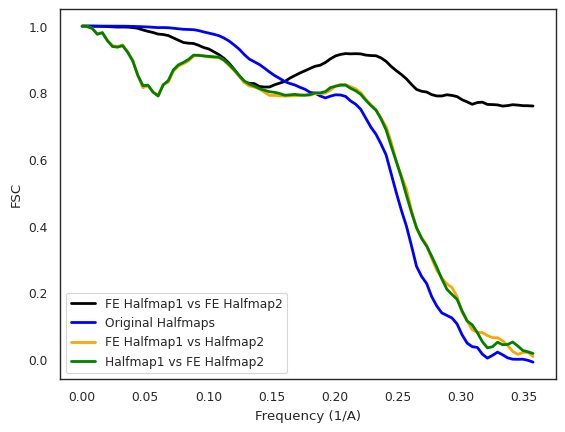

In [18]:
plt.plot(freq, fsc_fe1_fe2, label="FE Halfmap1 vs FE Halfmap2", color="black", linewidth=2.0)
plt.plot(freq, fsc_halfmaps_original, label="Original Halfmaps", color="blue", linewidth=2.0)
plt.plot(freq, fsc_fe1_half2, label="FE Halfmap1 vs Halfmap2", color="orange", linewidth=2.0)
plt.plot(freq, fsc_fe2_half1, label="Halfmap1 vs FE Halfmap2", color="green", linewidth=2.0)
plt.legend()
plt.xlabel("Frequency (1/A)")
plt.ylabel("FSC")

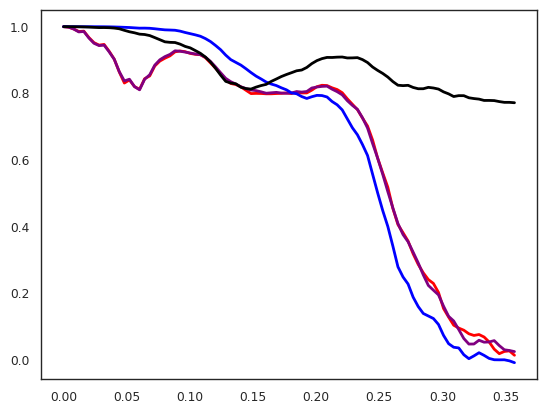

In [21]:
fsc_maskedfe1_half2 = calculate_fsc_maps(masked_halfmap1_fe, masked_halfmap2)
fsc_maskedfe2_half1 = calculate_fsc_maps(masked_halfmap1, masked_halfmap2_fe)
fsc_maskedfe1_fe2 = calculate_fsc_maps(masked_halfmap1_fe, masked_halfmap2_fe)

plt.plot(freq, fsc_maskedfe1_half2, label="Masked FE Halfmap1 vs Halfmap2", color="red", linewidth=2.0)
plt.plot(freq, fsc_maskedfe2_half1, label="Masked Halfmap1 vs FE Halfmap2", color="purple", linewidth=2.0)
plt.plot(freq, fsc_halfmaps_original, label="Masked Original Halfmaps", color="blue", linewidth=2.0)
plt.plot(freq, fsc_maskedfe1_fe2, label="Masked FE Halfmap1 vs FE Halfmap2", color="black", linewidth=2.0)


(180, 180, 180)


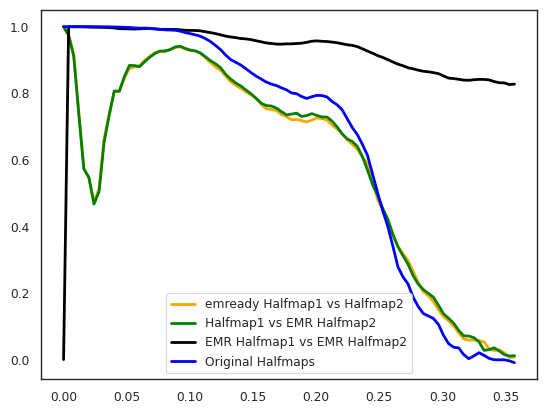

In [31]:
from locscale.include.emmer.ndimage.map_utils import resample_map
emready_half1_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/halfmap_fsc_shifts/emready_3061_half1.mrc"
emready_half2_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/halfmap_fsc_shifts/emready_3061_half2.mrc"
emready_h1, emready_apix = load_map(emready_half1_path)
emready_h2, _ = load_map(emready_half2_path)
emready_h1_resampled = resample_map(emready_h1, apix=emready_apix, apix_new=apix, order=2, assert_shape=180)
emready_h2_resampled = resample_map(emready_h2, apix=emready_apix, apix_new=apix, order=2, assert_shape=180)
print(emready_h1_resampled.shape)
#emready_h2, _ = load_map(emready_half2_path)

fsc_emready1_half2 = calculate_fsc_maps(emready_h1_resampled, masked_halfmap2)
fsc_emready2_half1 = calculate_fsc_maps(masked_halfmap1, emready_h2_resampled)
fsc_emready1_2 = calculate_fsc_maps(emready_h1_resampled, emready_h2_resampled)


plt.plot(freq, fsc_emready1_half2, label="emready Halfmap1 vs Halfmap2", color="orange", linewidth=2.0)
plt.plot(freq, fsc_emready2_half1, label="Halfmap1 vs EMR Halfmap2", color="green", linewidth=2.0)
plt.plot(freq, fsc_emready1_2, label="EMR Halfmap1 vs EMR Halfmap2", color="black", linewidth=2.0)
plt.plot(freq, fsc_halfmaps_original, label="Original Halfmaps", color="blue", linewidth=2.0)
plt.legend()
                                      


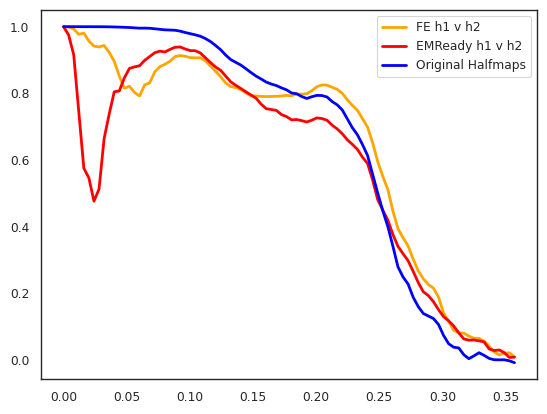

In [33]:
plt.plot(freq, fsc_fe1_half2, label="FE h1 v h2", color="orange", linewidth=2.0)
plt.plot(freq, fsc_emready1_half2, label="EMReady h1 v h2", color="red", linewidth=2.0)
plt.plot(freq, fsc_halfmaps_original, label="Original Halfmaps", color="blue", linewidth=2.0)
plt.legend()

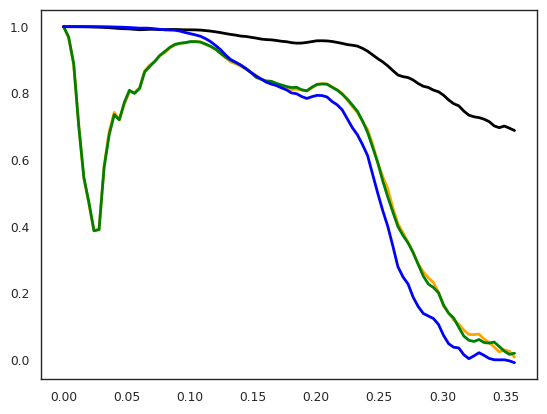

In [34]:
# do same for deepemhancer
deepemhancer_half1_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/halfmap_fsc_shifts/emd_3061_deepemhancer_half1.mrc"
deepemhancer_half2_path = "/home/abharadwaj1/papers/elife_paper/figure_information/data/halfmap_fsc_shifts/emd_3061_deepemhancer_half2.mrc"
deepemhancer_h1, deepemhancer_apix = load_map(deepemhancer_half1_path)
deepemhancer_h2, _ = load_map(deepemhancer_half2_path)

fsc_deepemhancer1_half2 = calculate_fsc_maps(deepemhancer_h1, masked_halfmap2)
fsc_deepemhancer2_half1 = calculate_fsc_maps(masked_halfmap1, deepemhancer_h2)
fsc_deepemhancer1_2 = calculate_fsc_maps(deepemhancer_h1, deepemhancer_h2)

plt.plot(freq, fsc_deepemhancer1_half2, label="DeepEMhancer Halfmap1 vs Halfmap2", color="orange", linewidth=2.0)
plt.plot(freq, fsc_deepemhancer2_half1, label="Halfmap1 vs DeepEMhancer Halfmap2", color="green", linewidth=2.0)
plt.plot(freq, fsc_deepemhancer1_2, label="DeepEMhancer Halfmap1 vs DeepEMhancer Halfmap2", color="black", linewidth=2.0)
plt.plot(freq, fsc_halfmaps_original, label="Original Halfmaps", color="blue", linewidth=2.0)

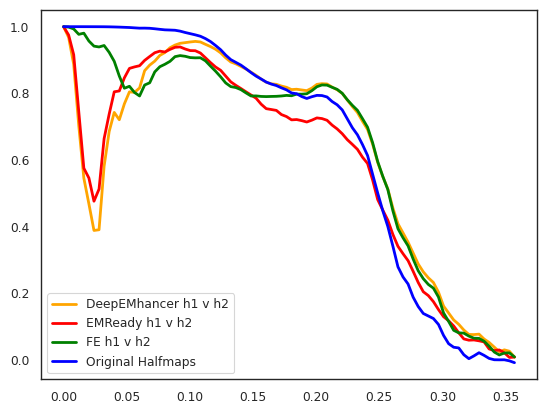

In [37]:
plt.plot(freq, fsc_deepemhancer1_half2, label="DeepEMhancer h1 v h2", color="orange", linewidth=2.0)
plt.plot(freq, fsc_emready1_half2, label="EMReady h1 v h2", color="red", linewidth=2.0)
plt.plot(freq, fsc_fe1_half2, label="FE h1 v h2", color="green", linewidth=2.0)
plt.plot(freq, fsc_halfmaps_original, label="Original Halfmaps", color="blue", linewidth=2.0)
plt.legend()
